# Tracking a Moving Dot with Traditional (Non-AI) Filters
### A from-scratch implementation of the Kalman Filter and the Alpha-Beta Filter

---

## 1. Motivation

Imagine a radar station tracking an aircraft, a security camera tracking a walking
person reduced to a single "blob" centroid, or a simple video tracking a bouncing
ball reduced to a **dot**. In every one of these cases we only get **noisy
measurements** of the dot's position at each time step — never the truth.

If we simply plotted the raw measurements, the trajectory would look shaky and
jittery, because every sensor (a camera, a radar, a mouse pointer, a GPS
receiver) adds **measurement noise**.

**Goal of this notebook:** recover a smooth, accurate estimate of a moving dot's
position *and* velocity from noisy position-only measurements, using
**classical estimation theory** — no machine learning, no neural networks, no
black boxes. Every matrix operation, every random number, and every filter
equation is implemented by hand in pure Python.

> **Note on tools used:** All *tracking mathematics* (linear algebra, random
> number generation, the filters themselves) is implemented from scratch with
> plain Python lists — no NumPy/SciPy/OpenCV. `matplotlib` is used **only** at
> the very end to *draw* the results on screen; it performs no computation
> related to tracking and could be swapped for writing pixels to a PPM file
> without changing a single line of filter logic.

## 2. The general problem: state estimation

A moving dot at time step $k$ has a **true (hidden) state** we would like to
know, e.g.

$$
\mathbf{x}_k = \begin{bmatrix} x_k \\ y_k \\ \dot{x}_k \\ \dot{y}_k \end{bmatrix}
\quad \text{(position and velocity in 2D)}
$$

We never observe $\mathbf{x}_k$ directly. Instead, at every time step, a sensor
gives us a **noisy measurement** of (part of) the state:

$$
\mathbf{z}_k = H\mathbf{x}_k + \mathbf{v}_k, \qquad \mathbf{v}_k \sim \mathcal{N}(0, R)
$$

Here $H$ extracts the part of the state we can measure (usually just position),
and $\mathbf{v}_k$ is random measurement noise.

We also know (approximately) how the dot's true state evolves in time — its
**motion model**:

$$
\mathbf{x}_{k} = F\mathbf{x}_{k-1} + \mathbf{w}_{k-1}, \qquad \mathbf{w}_{k-1} \sim \mathcal{N}(0, Q)
$$

$F$ is the **state-transition matrix** (physics of motion), and
$\mathbf{w}_{k-1}$ is **process noise** — the model is never perfect (the dot
might accelerate unexpectedly, bounce, etc.).

**Filtering** is the task of combining:
1. what the motion model *predicts* the state should be, with
2. what the noisy sensor *measures*,

to produce a statistically optimal estimate — better than either source alone.
This is the essence of every "traditional" (model-based, non-learned) tracking
filter: **predict, then correct**.


## 3. A quick taxonomy of traditional tracking filters

| Filter | Idea | Handles velocity? | Optimality | Complexity |
|---|---|---|---|---|
| **Moving average** | Average the last $N$ measurements | No (lags behind motion) | Not optimal | Trivial |
| **Exponential smoothing** | Weighted average, more weight to recent samples | No | Not optimal | Trivial |
| **Alpha-Beta ($g$-$h$) filter** | Fixed-gain predict/correct on position & velocity | Yes | Sub-optimal (fixed gain) | Very low |
| **Kalman Filter** | Bayesian-optimal predict/correct with *time-varying, self-tuning* gain (for linear-Gaussian systems) | Yes | Optimal (min. mean-square error, linear-Gaussian case) | Low (matrix algebra) |
| **Extended/Unscented Kalman Filter** | Kalman filter generalized to non-linear motion/measurement | Yes | Approximately optimal | Medium |
| **Particle Filter** | Represents the belief as a cloud of weighted random samples | Yes | Optimal for arbitrary (non-Gaussian) noise, given enough particles | High |

This notebook implements the two most important **linear** members of this
family from scratch:

* the **Alpha-Beta filter** — because it's the simplest possible
  predict/correct tracker and builds intuition for the Kalman filter, and
* the **Kalman Filter** — the workhorse of classical tracking, and provably
  the *best possible linear estimator* when noise is Gaussian.

We will simulate a moving dot, corrupt its position with noise, track it with
both filters, and compare their accuracy.


## 4. Linear algebra from scratch

The Kalman filter is fundamentally a sequence of matrix operations:
multiplication, transposition, addition, and inversion. Since we are not
allowed to use NumPy, we implement a minimal `Matrix` class ourselves, backed
by a plain Python list-of-lists.

### 4.1 What we need
* **Addition / subtraction** — combining covariances and states.
* **Multiplication** — applying transition/measurement matrices (and scalar
  multiplication for gain calculations).
* **Transpose** — needed everywhere in Kalman equations ($F^T$, $H^T$).
* **Matrix inverse** — needed once per Kalman update, to invert the
  *innovation covariance* $S$. We implement this via **Gauss-Jordan
  elimination with partial pivoting**, a standard, numerically-reasonable,
  from-scratch method for inverting a square matrix:

  1. Augment the matrix $A$ ($n \times n$) with the identity matrix $I$ to
     form $[A \mid I]$.
  2. Use row operations (swap, scale, eliminate) to reduce the left block to
     $I$. Partial pivoting (swapping in the row with the largest pivot
     element) keeps the elimination numerically stable.
  3. Whatever ends up on the right block is $A^{-1}$, because the same row
     operations that turn $A$ into $I$ turn $I$ into $A^{-1}$.

This is exactly the algorithm taught in introductory linear algebra courses,
just written out in Python.


In [1]:
class Matrix:
    '''A minimal, dependency-free 2D matrix class supporting the handful of
    operations a Kalman filter needs: +, -, *, transpose, and inverse.
    Internally stored as a list of lists: self.data[row][col].
    '''

    def __init__(self, data):
        # data: list of lists (rows of the matrix)
        self.data = [row[:] for row in data]
        self.rows = len(data)
        self.cols = len(data[0]) if self.rows > 0 else 0

    # ---- constructors -----------------------------------------------------
    @staticmethod
    def zeros(rows, cols):
        return Matrix([[0.0 for _ in range(cols)] for _ in range(rows)])

    @staticmethod
    def identity(n):
        return Matrix([[1.0 if i == j else 0.0 for j in range(n)] for i in range(n)])

    @staticmethod
    def from_column(vec):
        '''Build a column matrix (n x 1) from a flat python list.'''
        return Matrix([[v] for v in vec])

    # ---- basic ops ----------------------------------------------------------
    def __add__(self, other):
        assert self.rows == other.rows and self.cols == other.cols, "shape mismatch in +"
        return Matrix([[self.data[i][j] + other.data[i][j] for j in range(self.cols)]
                        for i in range(self.rows)])

    def __sub__(self, other):
        assert self.rows == other.rows and self.cols == other.cols, "shape mismatch in -"
        return Matrix([[self.data[i][j] - other.data[i][j] for j in range(self.cols)]
                        for i in range(self.rows)])

    def __mul__(self, other):
        # scalar multiplication
        if isinstance(other, (int, float)):
            return Matrix([[self.data[i][j] * other for j in range(self.cols)]
                            for i in range(self.rows)])
        # matrix multiplication
        assert self.cols == other.rows, "shape mismatch in matrix multiply"
        result = Matrix.zeros(self.rows, other.cols)
        for i in range(self.rows):
            for k in range(self.cols):
                a_ik = self.data[i][k]
                if a_ik == 0:
                    continue
                for j in range(other.cols):
                    result.data[i][j] += a_ik * other.data[k][j]
        return result

    __rmul__ = __mul__

    def transpose(self):
        return Matrix([[self.data[i][j] for i in range(self.rows)] for j in range(self.cols)])

    def inverse(self):
        '''Gauss-Jordan elimination with partial pivoting.
        Returns the inverse of this (square) matrix.'''
        n = self.rows
        assert n == self.cols, "only square matrices can be inverted"

        # Build augmented matrix [A | I]
        aug = [self.data[i][:] + [1.0 if i == j else 0.0 for j in range(n)] for i in range(n)]

        for col in range(n):
            # --- partial pivoting: find row with largest absolute value in this column
            pivot_row = max(range(col, n), key=lambda r: abs(aug[r][col]))
            if abs(aug[pivot_row][col]) < 1e-12:
                raise ValueError("Matrix is singular and cannot be inverted")
            aug[col], aug[pivot_row] = aug[pivot_row], aug[col]

            # --- normalize pivot row so pivot element becomes 1
            pivot_val = aug[col][col]
            aug[col] = [v / pivot_val for v in aug[col]]

            # --- eliminate this column from every other row
            for r in range(n):
                if r != col:
                    factor = aug[r][col]
                    if factor != 0.0:
                        aug[r] = [aug[r][c] - factor * aug[col][c] for c in range(2 * n)]

        inv_data = [row[n:] for row in aug]
        return Matrix(inv_data)

    def to_flat(self):
        '''Flatten a column/row matrix into a plain python list.'''
        if self.cols == 1:
            return [self.data[i][0] for i in range(self.rows)]
        if self.rows == 1:
            return self.data[0][:]
        raise ValueError("to_flat only works on row or column vectors")

    def __repr__(self):
        rows = ["[" + ", ".join(f"{v: .4f}" for v in row) + "]" for row in self.data]
        return "Matrix(\n  " + ",\n  ".join(rows) + "\n)"


# --- quick self-test of the Matrix class -----------------------------------
A = Matrix([[4, 7], [2, 6]])
A_inv = A.inverse()
check = A * A_inv  # should be (very close to) the identity matrix
print("A =", A)
print("A^-1 =", A_inv)
print("A * A^-1 (should be identity) =", check)


A = Matrix(
  [ 4.0000,  7.0000],
  [ 2.0000,  6.0000]
)
A^-1 = Matrix(
  [ 0.6000, -0.7000],
  [-0.2000,  0.4000]
)
A * A^-1 (should be identity) = Matrix(
  [ 1.0000,  0.0000],
  [ 0.0000,  1.0000]
)


## 5. Random numbers from scratch (for simulating noise)

To simulate a *realistic* tracking scenario we need to (a) simulate a ground
truth trajectory, and (b) corrupt it with **Gaussian (normal) noise**, since
that is the noise model the Kalman filter is mathematically derived for.

Python's `random` module is itself a library, so to keep things fully
from-scratch we build our own:

1. **Linear Congruential Generator (LCG)** — the classic algorithm for
   pseudo-random numbers:
   $$ s_{n+1} = (a \cdot s_n + c) \bmod m $$
   which produces a deterministic but statistically "random-looking" sequence
   of integers, which we scale to $[0, 1)$ to get uniform random numbers.

2. **Box-Muller transform** — converts two independent uniform random numbers
   $u_1, u_2 \in (0, 1)$ into a sample from a **standard normal distribution**:
   $$ z = \sqrt{-2 \ln u_1}\, \cos(2\pi u_2) $$
   This is the standard technique for generating Gaussian noise without any
   built-in `random.gauss`/`numpy.random.normal` function.


In [2]:
import math

class SimpleRNG:
    '''Linear Congruential Generator + Box-Muller transform,
    implemented from scratch (no `random` module).'''

    def __init__(self, seed=42):
        # Parameters from Numerical Recipes' well-tested 32-bit LCG
        self.m = 2 ** 32
        self.a = 1664525
        self.c = 1013904223
        self.state = seed % self.m

    def uniform(self):
        '''Returns a uniform random float in (0, 1).'''
        self.state = (self.a * self.state + self.c) % self.m
        # add a tiny epsilon so we never return exactly 0 (needed for log() in Box-Muller)
        return (self.state / self.m) * (1 - 1e-12) + 1e-12

    def gauss(self, mu=0.0, sigma=1.0):
        '''Box-Muller transform: turns 2 uniform samples into 1 standard-normal sample.'''
        u1 = self.uniform()
        u2 = self.uniform()
        z0 = math.sqrt(-2.0 * math.log(u1)) * math.cos(2.0 * math.pi * u2)
        return mu + sigma * z0


# quick sanity check: mean/std of many samples should be close to (0, 1)
rng = SimpleRNG(seed=1)
samples = [rng.gauss(0, 1) for _ in range(5000)]
mean = sum(samples) / len(samples)
var = sum((s - mean) ** 2 for s in samples) / len(samples)
print(f"sample mean = {mean:.4f} (expect close to 0)")
print(f"sample std  = {math.sqrt(var):.4f} (expect close to 1)")


sample mean = 0.0107 (expect close to 0)
sample std  = 1.0021 (expect close to 1)


## 6. Simulating a moving dot with noisy measurements

We now generate a **ground-truth trajectory** for a dot moving in 2D with a
mostly-constant velocity but a bit of random "wobble" (representing small,
unmodeled accelerations — this is exactly what the process noise $Q$ in the
Kalman filter is meant to account for). We then generate **noisy
measurements** by adding Gaussian noise to the true position — simulating,
e.g., a shaky camera-based centroid detector.

The true state evolves as:

$$
x_{k} = x_{k-1} + \dot{x}_{k-1}\,\Delta t, \qquad
\dot{x}_{k} = \dot{x}_{k-1} + a_x\,\Delta t
$$

(and the same for $y$), where $a_x, a_y$ are small random accelerations drawn
fresh every step (unknown to the tracker — this is the "true" process noise).


In [3]:
dt = 1.0          # time between frames (seconds)
n_steps = 60       # number of frames to simulate
process_noise_std = 0.05   # true random acceleration magnitude (unknown to filters)
measurement_noise_std = 3.0  # sensor noise on measured position (pixels)

sim_rng = SimpleRNG(seed=7)

# true initial state: position (0,0), velocity (1.2, 0.8) units/frame
true_x, true_y = 0.0, 0.0
true_vx, true_vy = 1.2, 0.8

ground_truth = []       # list of (x, y) true positions
measurements = []       # list of (x, y) noisy measured positions

for k in range(n_steps):
    # random small acceleration disturbs the "constant velocity" assumption
    ax = sim_rng.gauss(0, process_noise_std)
    ay = sim_rng.gauss(0, process_noise_std)

    true_vx += ax * dt
    true_vy += ay * dt
    true_x += true_vx * dt
    true_y += true_vy * dt

    ground_truth.append((true_x, true_y))

    # sensor sees only a noisy version of the true position
    meas_x = true_x + sim_rng.gauss(0, measurement_noise_std)
    meas_y = true_y + sim_rng.gauss(0, measurement_noise_std)
    measurements.append((meas_x, meas_y))

print("First 5 ground-truth points:", ground_truth[:5])
print("First 5 noisy measurements :", measurements[:5])


First 5 ground-truth points: [(1.2724274714729469, 0.8443888725640973), (2.6599551111525024, 1.6772620684231088), (4.016788641012815, 2.5467035117047887), (5.35470794779988, 3.5083055040805675), (6.617391330818352, 4.5008567992484)]
First 5 noisy measurements : [(5.8116786463548635, 4.890765281662764), (-0.9519013765003628, 2.192781057641799), (-0.22837732904216068, 2.5111719452929586), (-0.5514255083097259, 6.433586860408635), (9.306112872215333, 0.38545888837253006)]


## 7. The Kalman Filter — theory

The Kalman filter (Rudolf Kálmán, 1960) is the **optimal linear estimator**
for a system with:

* linear state transition: $\mathbf{x}_k = F\mathbf{x}_{k-1} + \mathbf{w}_{k-1}$
* linear measurement: $\mathbf{z}_k = H\mathbf{x}_k + \mathbf{v}_k$
* Gaussian process noise $\mathbf{w} \sim \mathcal{N}(0, Q)$ and measurement
  noise $\mathbf{v} \sim \mathcal{N}(0, R)$

It maintains a running **belief** about the state as a Gaussian distribution,
fully described by a mean $\hat{\mathbf{x}}$ (best-guess state) and a
covariance $P$ (uncertainty of that guess). Every step alternates two phases:

### 7.1 Predict (time update)
Uses the motion model to *project* the state forward, before seeing the new
measurement:

$$
\hat{\mathbf{x}}_{k}^{-} = F\,\hat{\mathbf{x}}_{k-1}
$$
$$
P_{k}^{-} = F P_{k-1} F^T + Q
$$

Intuition: the mean simply moves according to the physics model $F$. The
covariance *grows* (uncertainty increases) because time has passed without
new information, plus we add $Q$ to account for the fact the model itself is
imperfect.

### 7.2 Update / Correct (measurement update)
Uses the new noisy measurement $\mathbf{z}_k$ to correct the prediction:

$$
\mathbf{y}_k = \mathbf{z}_k - H\hat{\mathbf{x}}_{k}^{-} \quad \text{(innovation: measurement} - \text{predicted measurement)}
$$
$$
S_k = H P_{k}^{-} H^T + R \quad \text{(innovation covariance)}
$$
$$
K_k = P_{k}^{-} H^T S_k^{-1} \quad \text{(Kalman gain)}
$$
$$
\hat{\mathbf{x}}_{k} = \hat{\mathbf{x}}_{k}^{-} + K_k \mathbf{y}_k
$$
$$
P_{k} = (I - K_k H)\,P_{k}^{-}
$$

**Intuition behind the Kalman gain $K_k$:** it is a matrix that decides,
*for every state variable*, how much to trust the new measurement versus the
prediction:

* If measurement noise $R$ is large (sensor is unreliable) → $K$ shrinks →
  the filter trusts its own prediction more.
* If prediction uncertainty $P^{-}$ is large (model has drifted / just
  started) → $K$ grows → the filter trusts the new measurement more.

This automatic, *optimal* balancing — recomputed every single step — is what
distinguishes the Kalman filter from a fixed-gain filter like Alpha-Beta.

### 7.3 Our specific model: constant-velocity motion, position-only sensor

State vector (what we track):
$$
\mathbf{x} = \begin{bmatrix} x \\ y \\ \dot{x} \\ \dot{y} \end{bmatrix}
$$

State transition matrix (constant velocity over time step $\Delta t$):
$$
F = \begin{bmatrix}
1 & 0 & \Delta t & 0 \\
0 & 1 & 0 & \Delta t \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
$$

Measurement matrix (sensor only observes position, not velocity):
$$
H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}
$$

Process noise covariance $Q$: models uncertainty from unmodeled acceleration.
A standard choice (discretized white-noise-acceleration model) is:

$$
Q = q \begin{bmatrix}
\Delta t^4/4 & 0 & \Delta t^3/2 & 0 \\
0 & \Delta t^4/4 & 0 & \Delta t^3/2 \\
\Delta t^3/2 & 0 & \Delta t^2 & 0 \\
0 & \Delta t^3/2 & 0 & \Delta t^2
\end{bmatrix}
$$

where $q$ is a small tunable constant representing expected acceleration
variance.

Measurement noise covariance $R$ (assume independent x/y sensor noise with
std. dev. $\sigma_r$):
$$
R = \begin{bmatrix} \sigma_r^2 & 0 \\ 0 & \sigma_r^2 \end{bmatrix}
$$


## 8. Kalman Filter — implementation from scratch

We now translate the equations above directly into code, using only our
hand-built `Matrix` class.


In [4]:
class KalmanFilter:
    def __init__(self, dt, q, sigma_r, initial_pos):
        self.dt = dt

        # state: [x, y, vx, vy]^T -- start with given position, zero velocity
        x0, y0 = initial_pos
        self.x = Matrix.from_column([x0, y0, 0.0, 0.0])

        # initial covariance: high uncertainty in velocity (we truly don't know it yet)
        self.P = Matrix([
            [10.0,  0.0,  0.0,  0.0],
            [ 0.0, 10.0,  0.0,  0.0],
            [ 0.0,  0.0, 100.0, 0.0],
            [ 0.0,  0.0,  0.0, 100.0],
        ])

        # state transition matrix F (constant velocity model)
        self.F = Matrix([
            [1, 0, dt, 0],
            [0, 1, 0, dt],
            [0, 0, 1,  0],
            [0, 0, 0,  1],
        ])

        # measurement matrix H (we observe position only)
        self.H = Matrix([
            [1, 0, 0, 0],
            [0, 1, 0, 0],
        ])

        # process noise covariance Q (discretized white-noise-acceleration model)
        dt2 = dt * dt
        dt3 = dt2 * dt
        dt4 = dt3 * dt
        self.Q = Matrix([
            [dt4 / 4, 0,       dt3 / 2, 0],
            [0,       dt4 / 4, 0,       dt3 / 2],
            [dt3 / 2, 0,       dt2,     0],
            [0,       dt3 / 2, 0,       dt2],
        ]) * q

        # measurement noise covariance R
        self.R = Matrix([
            [sigma_r ** 2, 0],
            [0, sigma_r ** 2],
        ])

        self.I = Matrix.identity(4)

    def predict(self):
        '''Time update: project state and covariance forward one step.'''
        self.x = self.F * self.x
        self.P = self.F * self.P * self.F.transpose() + self.Q

    def update(self, z_x, z_y):
        '''Measurement update: correct the prediction with a new noisy measurement.'''
        z = Matrix.from_column([z_x, z_y])

        y = z - (self.H * self.x)                              # innovation
        S = self.H * self.P * self.H.transpose() + self.R      # innovation covariance
        K = self.P * self.H.transpose() * S.inverse()           # Kalman gain

        self.x = self.x + (K * y)
        self.P = (self.I - (K * self.H)) * self.P

    def position(self):
        flat = self.x.to_flat()
        return flat[0], flat[1]

    def velocity(self):
        flat = self.x.to_flat()
        return flat[2], flat[3]


In [5]:
# --- run the Kalman filter over the simulated measurements -----------------
kf = KalmanFilter(dt=dt, q=0.02, sigma_r=measurement_noise_std, initial_pos=measurements[0])

kalman_estimates = []
for (mx, my) in measurements:
    kf.predict()
    kf.update(mx, my)
    kalman_estimates.append(kf.position())

print("First 5 Kalman estimates:", kalman_estimates[:5])


First 5 Kalman estimates: [(5.8116786463548635, 4.890765281662764), (0.3051555528193548, 2.6942196083117613), (-1.0653319709546052, 2.1682662573493348), (-1.7367475416249607, 4.345129369836805), (3.2093526678027278, 2.3021115821336857)]


## 9. The Alpha-Beta ($g$-$h$) filter — a simpler cousin

Before Kalman's 1960 paper, radar trackers commonly used the **Alpha-Beta
filter** — the same predict/correct *structure* as the Kalman filter, but
with **fixed** gains $\alpha$ (for position) and $\beta$ (for velocity)
chosen by hand, instead of an optimal, self-adjusting Kalman gain $K$.

For each independent axis (we apply this separately to $x$ and $y$):

**Predict:**
$$
x_k^{-} = x_{k-1} + v_{k-1}\Delta t, \qquad v_k^{-} = v_{k-1}
$$

**Correct**, given measurement $z_k$:
$$
r_k = z_k - x_k^{-} \quad \text{(residual)}
$$
$$
x_k = x_k^{-} + \alpha\, r_k
$$
$$
v_k = v_k^{-} + \frac{\beta}{\Delta t}\, r_k
$$

Because $\alpha, \beta$ are fixed constants rather than a recomputed optimal
gain, this filter is much cheaper (no matrices, no inversion) but **not**
statistically optimal, and it does not carry an explicit notion of
uncertainty (no $P$ matrix). It's a great baseline to compare the Kalman
filter against.


In [6]:
class AlphaBetaFilter:
    '''Tracks a single scalar axis (call twice: once for x, once for y).'''

    def __init__(self, dt, alpha, beta, initial_pos, initial_vel=0.0):
        self.dt = dt
        self.alpha = alpha
        self.beta = beta
        self.x = initial_pos
        self.v = initial_vel

    def step(self, z):
        # predict
        x_pred = self.x + self.v * self.dt
        v_pred = self.v

        # correct
        residual = z - x_pred
        self.x = x_pred + self.alpha * residual
        self.v = v_pred + (self.beta / self.dt) * residual

        return self.x


# --- run alpha-beta filter over the simulated measurements ------------------
ab_x = AlphaBetaFilter(dt, alpha=0.4, beta=0.15, initial_pos=measurements[0][0])
ab_y = AlphaBetaFilter(dt, alpha=0.4, beta=0.15, initial_pos=measurements[0][1])

alphabeta_estimates = []
for (mx, my) in measurements:
    ex = ab_x.step(mx)
    ey = ab_y.step(my)
    alphabeta_estimates.append((ex, ey))

print("First 5 Alpha-Beta estimates:", alphabeta_estimates[:5])


First 5 Alpha-Beta estimates: [(5.8116786463548635, 4.890765281662764), (3.106246637212773, 3.811571592054378), (1.1636748486538289, 3.048593153187923), (-0.33989532284296187, 4.079158874730076), (2.669248398648973, 2.6314113166927102)]


## 10. Quantitative comparison: Root Mean Square Error (RMSE)

To objectively compare the raw noisy measurements against the two filters, we
compute the **Root Mean Square Error** against the (known, because it's
simulated) ground truth:

$$
\text{RMSE} = \sqrt{\frac{1}{N}\sum_{k=1}^{N}\left[(x_k - \hat{x}_k)^2 + (y_k - \hat{y}_k)^2\right]}
$$

implemented with plain Python loops (no NumPy).


In [7]:
def rmse(truth, estimate):
    n = len(truth)
    total = 0.0
    for (tx, ty), (ex, ey) in zip(truth, estimate):
        total += (tx - ex) ** 2 + (ty - ey) ** 2
    return math.sqrt(total / n)

rmse_measurements = rmse(ground_truth, measurements)
rmse_kalman = rmse(ground_truth, kalman_estimates)
rmse_alphabeta = rmse(ground_truth, alphabeta_estimates)

print(f"RMSE of raw noisy measurements : {rmse_measurements:.3f}")
print(f"RMSE of Alpha-Beta filter      : {rmse_alphabeta:.3f}")
print(f"RMSE of Kalman filter          : {rmse_kalman:.3f}")


RMSE of raw noisy measurements : 4.270
RMSE of Alpha-Beta filter      : 2.794
RMSE of Kalman filter          : 2.555


## 11. Visualization

Finally, we plot the ground-truth trajectory, the raw noisy measurements, and
both filters' estimates on the same axes, so the smoothing/tracking effect is
visible directly. (As noted earlier, `matplotlib` here is purely for
*displaying* numbers we already computed by hand — no tracking math happens
in this cell.)


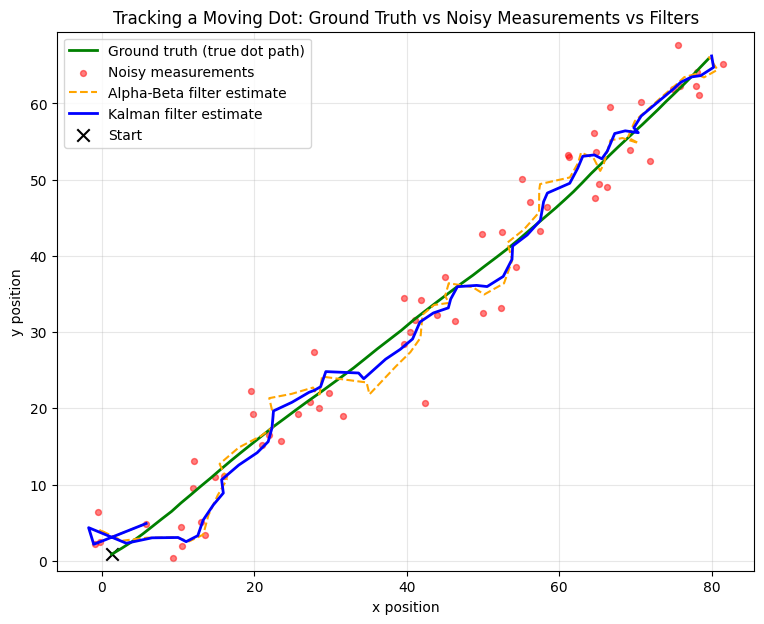

In [8]:
import matplotlib.pyplot as plt

gt_x = [p[0] for p in ground_truth]
gt_y = [p[1] for p in ground_truth]
mz_x = [p[0] for p in measurements]
mz_y = [p[1] for p in measurements]
kf_x = [p[0] for p in kalman_estimates]
kf_y = [p[1] for p in kalman_estimates]
ab_x_list = [p[0] for p in alphabeta_estimates]
ab_y_list = [p[1] for p in alphabeta_estimates]

plt.figure(figsize=(9, 7))
plt.plot(gt_x, gt_y, 'g-', linewidth=2, label='Ground truth (true dot path)')
plt.scatter(mz_x, mz_y, c='red', s=18, alpha=0.5, label='Noisy measurements')
plt.plot(ab_x_list, ab_y_list, 'orange', linewidth=1.5, linestyle='--', label='Alpha-Beta filter estimate')
plt.plot(kf_x, kf_y, 'blue', linewidth=2, label='Kalman filter estimate')

plt.scatter([gt_x[0]], [gt_y[0]], c='black', marker='x', s=80, label='Start')
plt.title('Tracking a Moving Dot: Ground Truth vs Noisy Measurements vs Filters')
plt.xlabel('x position')
plt.ylabel('y position')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()


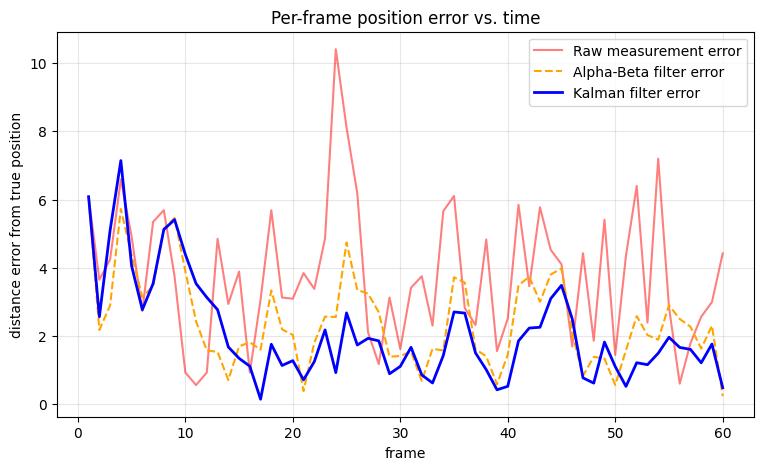

In [9]:
# Per-frame position error over time, for a second view of filter behaviour
frames = list(range(1, n_steps + 1))

def per_frame_error(truth, estimate):
    return [math.sqrt((tx - ex) ** 2 + (ty - ey) ** 2) for (tx, ty), (ex, ey) in zip(truth, estimate)]

err_meas = per_frame_error(ground_truth, measurements)
err_kf = per_frame_error(ground_truth, kalman_estimates)
err_ab = per_frame_error(ground_truth, alphabeta_estimates)

plt.figure(figsize=(9, 5))
plt.plot(frames, err_meas, 'r-', alpha=0.5, label='Raw measurement error')
plt.plot(frames, err_ab, 'orange', linestyle='--', label='Alpha-Beta filter error')
plt.plot(frames, err_kf, 'b-', linewidth=2, label='Kalman filter error')
plt.title('Per-frame position error vs. time')
plt.xlabel('frame')
plt.ylabel('distance error from true position')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 12. Discussion

* Both filters clearly **smooth** the jittery raw measurements, but the
  Kalman filter tracks the true path noticeably more tightly, and its
  advantage shows up directly in the lower RMSE printed above.
* Early in the sequence, the Kalman filter's estimate can lag slightly behind
  the true position — this is because the initial covariance $P_0$ encodes
  large uncertainty about velocity, so the filter needs a few frames to
  "learn" how fast the dot is really moving. Watch how the Kalman gain
  effectively adapts over the course of the run — try printing `kf.P` at
  different iterations to see the covariance shrink as confidence grows.
* The Alpha-Beta filter uses **the same $\alpha, \beta$ every frame**,
  regardless of how confident it should be — it cannot adapt the way the
  Kalman filter's gain $K_k$ does. Try changing `alpha`/`beta` above and
  notice the classic trade-off: larger gains track fast motion better but are
  noisier; smaller gains smooth more but lag behind turns.

### Limitations of this approach (and where to go next)
* **Linearity assumption:** both filters here assume the state evolves
  *linearly* ($F$, $H$ are constant matrices). A dot bouncing off walls,
  moving in a circle, or undergoing sharp non-linear maneuvers would need an
  **Extended Kalman Filter (EKF)** (linearizes $F$/$H$ around the current
  estimate every step) or an **Unscented Kalman Filter (UKF)** (propagates a
  small set of deterministically-chosen "sigma points" through the true
  non-linear model).
* **Gaussian noise assumption:** if noise is multi-modal or heavy-tailed (or
  if there are multiple dots and *data association* ambiguity — "which
  measurement belongs to which dot?"), a **Particle Filter** (Sequential
  Monte Carlo) represents the belief as a cloud of weighted random samples
  instead of a single Gaussian, and can handle much more general noise/motion
  models at the cost of more computation.
* **Multi-object tracking:** tracking *several* dots simultaneously adds the
  extra problem of **data association** (matching measurements to tracks),
  typically solved with algorithms such as the **Hungarian algorithm** (for
  optimal one-to-one assignment) or **Nearest-Neighbor / JPDA** methods,
  layered on top of a Kalman filter per track.

All of these remain "traditional" (non-AI, model-based, mathematically
derived) approaches — natural next steps once the single-dot, linear-Gaussian
case implemented here is well understood.
